In [13]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
from synthetic_observations import Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [14]:
import h5py
import os
import re

folder = "results"   # your results folder
all_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("valnorm_o29"):
        filepath = os.path.join(folder, filename)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            all_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]


In [15]:
start = int(0.005*wgrid.shape[-1])
end = int(0.995*wgrid.shape[-1])

s1 = int(0.005*inst_wgrid.shape[-1])
e1 = int(0.995*inst_wgrid.shape[-1])

start = np.searchsorted(wgrid, inst_wgrid[s1])
end = np.searchsorted(wgrid, inst_wgrid[e1])

(18468,) (18468,)
0.028905869282085554 0.03798214641436596
(18468,) (18468,)
0.007127240855844955 0.007614826722292316


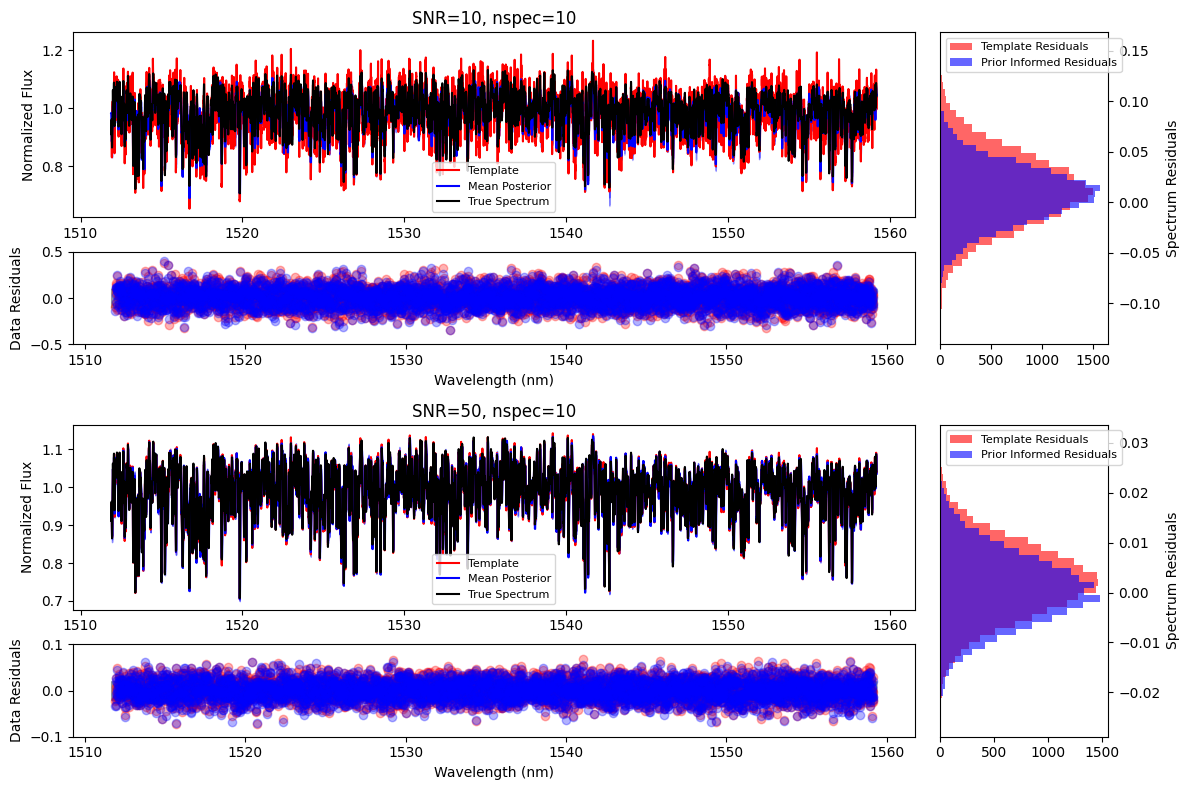

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- Pick which cases to compare (just change these tuples) ---
cases = [(0,10, 10),(0, 50, 10)]   # example: two SNR values, same nspec=25
Teffs= [3100,2300]
fig, axes = plt.subplots(len(cases), 1, figsize=(12, 4*len(cases)))

if len(cases) == 1:
    axes = [axes]  # make iterable if only one case

for ax_row, (i, snr, nspec) in zip(axes, cases):
    spectrum_analysis = all_data[(i, snr, nspec)]['spectrum']

    wavelength = wgrid[start:end]
    true_spec = spectrum_analysis['true_spectrum'][0,0][start:end]
    template = spectrum_analysis['template'][start:end]
    post = spectrum_analysis['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]
    mean = spectrum_analysis['posterior_spectrum_samples'][0,0,0,non_ones[0]:non_ones[-1]+1][start:end]
    print(true_spec.shape,mean.shape)
    # mean = np.percentile(post, [50], axis=[0,1])[0] 
    sigma_1 = np.percentile(post, [16, 84], axis=[0,1])
    sigma_2 = np.percentile(post, [2.5, 97.5], axis=[0,1])
    sigma_3 = np.percentile(post, [0.15, 99.85], axis=[0,1])

    temp_residuals = true_spec - template
    diff_residuals = true_spec - mean

    ## Data residuals 
    a = torch.tensor(true_spec).unsqueeze(0).unsqueeze(0)
    b = torch.tensor(wavelength)
    c = torch.tensor(inst_wgrid)
    data_forward = (forward_model(a,b,c,torch.tensor([[0]]),torch.tensor([[0]])))[0,0,s1:e1]+(torch.normal(0,1/snr,inst_wgrid[s1:e1].shape))
    d = torch.tensor(template).unsqueeze(0).unsqueeze(0)
    temp_forward = forward_model(d,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0,s1:e1]

    e = torch.tensor(mean).unsqueeze(0).unsqueeze(0)
    post_forward = forward_model(e,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0,s1:e1]


    # ---- Layout with 2x2 GridSpec ----
    gs = gridspec.GridSpecFromSubplotSpec(
        2, 2, width_ratios=[5,1], height_ratios=[2,1],
        wspace=0.05, hspace=0.25, subplot_spec=ax_row.get_subplotspec()
    )

    # --- Top left: full spectrum ---
    ax_full = fig.add_subplot(gs[0,0])
    ax_full.plot(wavelength, template, label="Template", color='red')
    ax_full.plot(wavelength, mean, label="Mean Posterior", color='blue')
    ax_full.plot(wavelength, true_spec, label="True Spectrum", color='black', linewidth=1.5)
    ax_full.fill_between(wavelength, sigma_3[0], sigma_3[1], color='blue', alpha=0.2)
    ax_full.fill_between(wavelength, sigma_2[0], sigma_2[1], color='blue', alpha=0.3)
    ax_full.fill_between(wavelength, sigma_1[0], sigma_1[1], color='blue', alpha=0.4)
    ax_full.legend(fontsize=8)
    ax_full.set_ylabel("Normalized Flux")
    ax_full.set_title(f"SNR={snr}, nspec={nspec}")
    # ax_full.set_xlim(1542,1545)
    # ax_full.set_xlim(1290,1292)
    # ax_full.set_ylim(0.5,1.3)

    # --- Bottom left: zoom-in spectrum subset via xlim ---
    ax_zoom = fig.add_subplot(gs[1,0])
    ax_zoom.fill_between(inst_wgrid, -1/snr, 1/snr, color='grey', alpha=0.75)

    ax_zoom.scatter(inst_wgrid[s1:e1], data_forward-temp_forward, color='red',alpha=0.3)
    ax_zoom.scatter(inst_wgrid[s1:e1], data_forward-post_forward, color='blue',alpha=0.3)
    # ax_zoom.scatter(wavelength,diff_residuals)
    # ax_zoom.plot(wavelength, true_spec, color='black', linewidth=1.5)
    # ax_zoom.fill_between(wavelength, sigma_3[0], sigma_3[1], color='blue', alpha=0.2)
    # ax_zoom.fill_between(wavelength, sigma_2[0], sigma_2[1], color='blue', alpha=0.3)
    # ax_zoom.fill_between(wavelength, sigma_1[0], sigma_1[1], color='blue', alpha=0.4)
    ax_zoom.set_xlabel("Wavelength (nm)")
    ax_zoom.set_ylabel("Data Residuals")
    # ax_zoom.set_xlim(1542,1545)
    # ax_zoom.set_xlim(1290,1292)
    ax_zoom.set_ylim(-5/snr,5/snr)  # zoom region

    # --- Right side: residual histograms (span both rows) ---
    ax_hist = fig.add_subplot(gs[:,1])  # spans rows 0 and 1
    ax_hist.hist(temp_residuals, bins=40, orientation="horizontal", color="red", alpha=0.6, label="Template Residuals")
    ax_hist.hist(diff_residuals, bins=40, orientation="horizontal", color="blue", alpha=0.6, label="Prior Informed Residuals")
    # ax_hist.set_ylim(-2/snr, 2/snr)
    ax_hist.yaxis.tick_right()
    ax_hist.yaxis.set_label_position("right")
    ax_hist.set_ylabel("Spectrum Residuals")
    ax_hist.legend(fontsize=8)
    print(np.sqrt(np.mean(diff_residuals**2)),np.sqrt(np.mean(temp_residuals**2)))


    ax_row.tick_params(labelbottom=False,bottom=False,left=False,labelleft=False)
    for spine in ax_row.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


In [17]:
import numpy as np

final_results = {}

for (i, snr, nspec), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_rmse": [],
        "template_rmse": [],
        "mala_rmse": [],
        "prior_rmse": [],
        "intrinsic_unc": [],
        "template_unc": [],
        "mala_unc": [],
        "prior_unc": [],
        "intrinsic_z_mean": [],
        "intrinsic_z_std": [],
        "template_z_mean": [],
        "template_z_std": [],
        "mala_z_mean": [],
        "mala_z_std": [],
        "prior_z_mean": [],
        "prior_z_std": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        prior = group["prior_rv"][()]
        mala = group["mala_samples"][()]   # shape: (n_samples,)
        # Point estimates for mala
        mala_mean = mala.mean(axis=0).mean(axis=0)#[0]
        mala_std = mala.std(axis=0).mean(axis=0)#[0]

        # --- RMSE ---
        results["intrinsic_rmse"].append(np.sqrt(np.mean((intrinsic - true) ** 2)))
        results["prior_rmse"].append(np.sqrt(np.mean((prior - true) ** 2)))
        results["template_rmse"].append(np.sqrt(np.mean((template - true) ** 2)))
        results["mala_rmse"].append(np.sqrt(np.mean((mala_mean - true) ** 2)))

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        prior_unc = group["prior_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        prior_z = (prior - true) / prior_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        

        results["intrinsic_z_mean"].append(intrinsic_z.mean())
        results["intrinsic_z_std"].append(intrinsic_z.std())
        results["intrinsic_unc"].append(intrinsic_unc.mean())
        results["template_unc"].append(template_unc.mean())
        results["prior_unc"].append(prior_unc.mean())
        results["mala_unc"].append(mala_std.mean())
        results["template_z_mean"].append(template_z.mean())
        results["template_z_std"].append(template_z.std())
        results["mala_z_mean"].append(mala_z.mean())
        results["mala_z_std"].append(mala_z.std())
        results["prior_z_mean"].append(prior_z.mean())
        results["prior_z_std"].append(prior_z.std())

    # --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: np.mean(v) for k, v in results.items()}


In [18]:
import pandas as pd

# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec"])
df_results = df_results.reset_index()

# df_results[(df_results['i']==6)&(df_results['nspec']==10)]
df_results

,i,snr,nspec,intrinsic_rmse,template_rmse,mala_rmse,prior_rmse,intrinsic_unc,template_unc,mala_unc,prior_unc,intrinsic_z_mean,intrinsic_z_std,template_z_mean,template_z_std,mala_z_mean,mala_z_std,prior_z_mean,prior_z_std
0,0,75,10,11.771681,13.876238,12.097339,11.995430,12.078156,12.154458,12.169582,12.220168,-0.040126,0.970217,-0.160916,1.126987,0.002151,0.994946,0.006802,0.978195
1,0,25,10,35.462151,72.056192,38.482087,38.390662,36.176652,33.716534,38.277430,38.469567,-0.041655,0.976110,-0.229629,2.201654,0.111536,0.997826,0.113211,0.989558
2,0,10,10,90.759366,189.197551,112.890258,113.078996,89.588148,42.398158,110.635214,111.195241,-0.045292,1.009182,-0.109801,4.576770,0.120554,1.014549,0.117269,1.012274
3,0,50,10,17.670135,23.755869,18.619693,18.415143,18.112400,18.218266,18.449806,18.510183,-0.040520,0.971261,-0.164865,1.296009,0.110684,1.007205,0.116413,0.985166


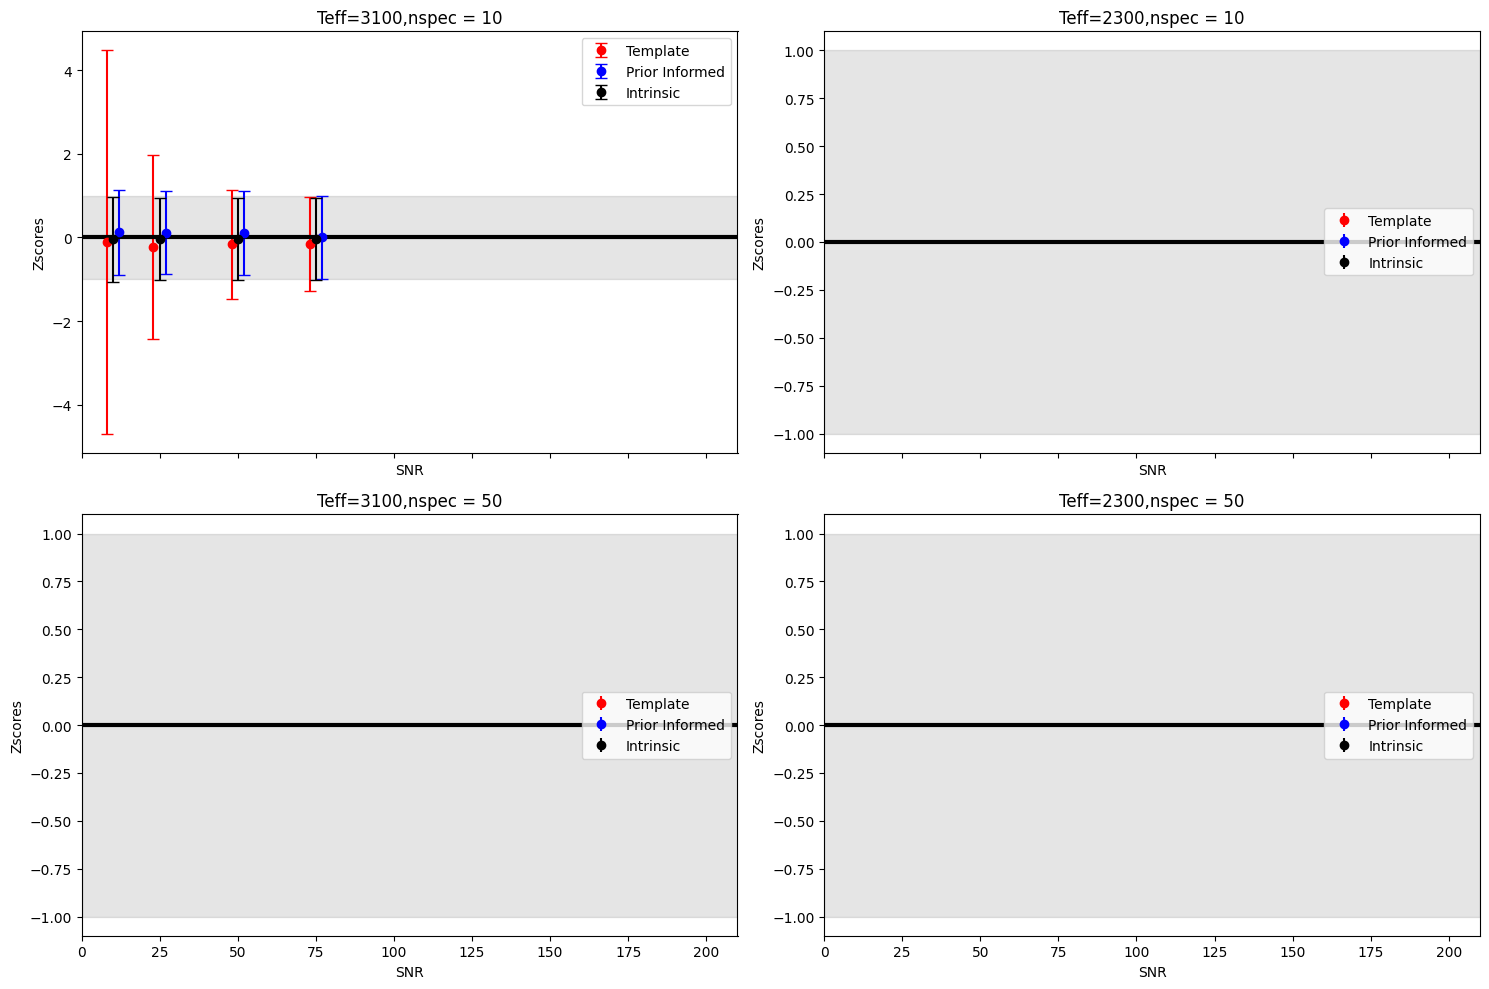

In [19]:
import matplotlib.pyplot as plt
Teffs= [3100,2300]
# Get all unique nspec values
nspec_values = [10, 50]

fig, axes = plt.subplots(len([1,0]), 2, figsize=(15, 5*len(nspec_values)), sharex=True)

# if len(nspec_values) == 1:
#     axes = [axes]  # make iterable if only one nspec

for i,s in enumerate([0,6]):
    for_one_spec = df_results[df_results['i']==s]
    for j,nspec in enumerate(nspec_values):
        group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")
        
        axes[j,i].errorbar(group["snr"]-2, group["template_z_mean"], group["template_z_std"],marker='o', ls="",capsize=4,c="r",label="Template")
        axes[j,i].errorbar(group["snr"]+2, group["mala_z_mean"], group["mala_z_std"], marker='o',c="b", ls="",capsize=4,label="Prior Informed")
        axes[j,i].errorbar(group["snr"], group["intrinsic_z_mean"], group["intrinsic_z_std"],marker='o', ls="",c="k",capsize=4,label="Intrinsic")

        axes[j,i].hlines(0,0,210,color="k",lw=3)
        axes[j,i].fill_between(np.linspace(0,210,10),-1,1,color="k",alpha=0.1)
        axes[j,i].set_ylabel("Zscores")
        axes[j,i].set_xlabel("SNR")
        axes[j,i].set_title(f"Teff={Teffs[i]},nspec = {nspec}")
        # axes[j,i].grid(True, alpha=0.3)
        # axes[j,i].set_yscale("log")
        # axes[j,i].set_xscale("log")
        axes[j,i].legend()
        axes[j,i].set_xlim(0,210)


# axes[-1].set_xlabel("SNR")
plt.tight_layout()
plt.show()


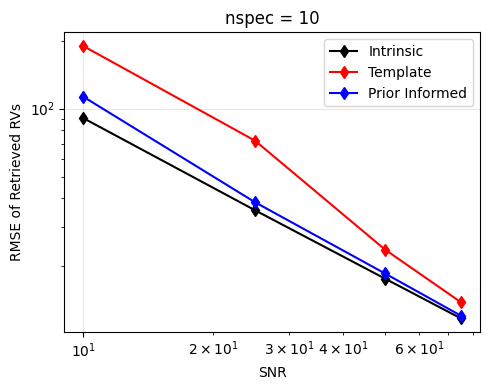

In [20]:
import matplotlib.pyplot as plt

Teffs = [3100, 2300]

for i, s in enumerate([0]):
    for_one_spec = df_results[df_results['i'] == s]
    nspec_values = sorted(for_one_spec["nspec"].unique())

    fig, axes = plt.subplots(1, len(nspec_values), figsize=(5 * len(nspec_values), 4), sharex=True)

    # ✅ Make axes always iterable
    if len(nspec_values) == 1:
        axes = [axes]

    for j, nspec in enumerate(nspec_values):
        group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")

        axes[j].plot(group["snr"], group["intrinsic_rmse"], marker="d", c="k", label="Intrinsic")
        axes[j].plot(group["snr"], group["template_rmse"], marker="d", c="r", label="Template")
        axes[j].plot(group["snr"], group["mala_rmse"], marker="d", c="b", label="Prior Informed")

        axes[j].set_ylabel("RMSE of Retrieved RVs")
        axes[j].set_title(f"nspec = {nspec}")
        axes[j].grid(True, alpha=0.3)
        axes[j].set_yscale("log")
        axes[j].set_xscale("log")
        axes[j].legend()
        axes[j].set_xlabel("SNR")

    plt.tight_layout()
    plt.show()


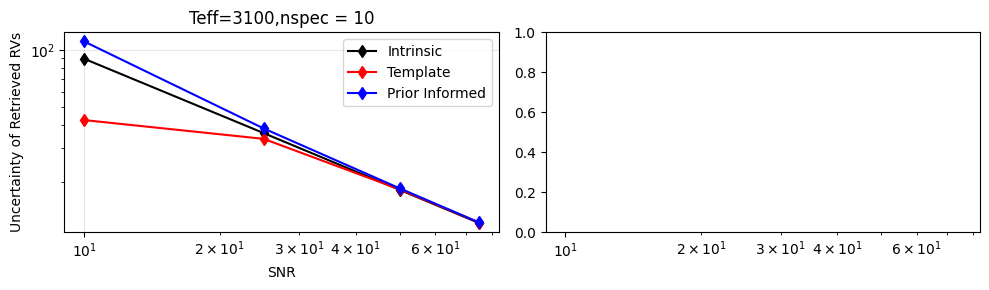

In [21]:
import matplotlib.pyplot as plt
Teffs= [3100,2300]

fig, axes = plt.subplots(1, 2, figsize=(10, 3*len(nspec_values)), sharex=True)

# if len(nspec_values) == 1:
#     axes = [axes]  # make iterable if only one nspec

for i,s in enumerate([0]):
    for_one_spec = df_results[df_results['i']==s]
    nspec_values = sorted(for_one_spec["nspec"].unique())
    for j,nspec in enumerate(nspec_values):
        group = for_one_spec[for_one_spec["nspec"] == nspec].sort_values("snr")
        
        axes[j].plot(group["snr"], group["intrinsic_unc"], marker="d", c="k",label="Intrinsic")
        axes[j].plot(group["snr"], group["template_unc"], marker="d", c="r",label="Template")
        axes[j].plot(group["snr"], group["mala_unc"], marker="d",c="b", label="Prior Informed")
        
        axes[j].set_ylabel("Uncertainty of Retrieved RVs")
        axes[j].set_title(f"Teff={Teffs[i]},nspec = {nspec}")
        axes[j].grid(True, alpha=0.3)
        axes[j].set_yscale("log")
        axes[j].set_xscale("log")
        axes[j].legend()
        axes[j].set_xlabel("SNR")


# axes[-1].set_xlabel("SNR")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np

final_results = {}

for (i, snr, nspec), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_z": [],
        "template_z": [],
        "mala_z": [],
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        mala = group["mala_samples"][()]   # shape: (n_samples,)
        # Point estimates for mala
        mala_mean = mala.mean(axis=(0,1))#[0]
        mala_std = mala.std(axis=(0,1))#.mean(axis=0)#[0]

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        

        results["intrinsic_z"].append(intrinsic_z)
        results["template_z"].append(template_z)
        results["mala_z"].append(mala_z)

    # --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: v for k, v in results.items()}


In [23]:
import pandas as pd

# Convert final_results into a DataFrame
df_results = pd.DataFrame.from_dict(final_results, orient="index")

# Turn the (snr, nspec) tuple into columns
df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["i","snr", "nspec"])
df_results = df_results.reset_index()

# df_results[(df_results['i']==6)&(df_results['nspec']==10)]
# df_results

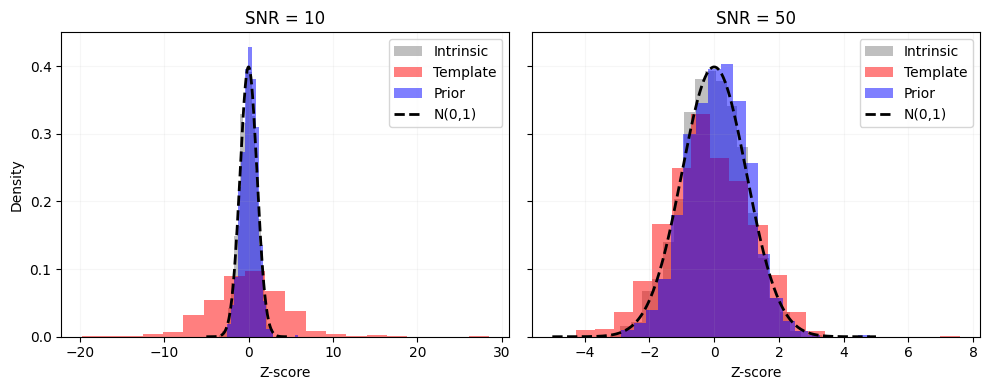

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
i_values = [0]                  # multiple i values
Teffs= [3100]
snr_values = [10, 50]            # three SNR values
columns_to_plot = ['intrinsic_z', 'template_z', 'mala_z']
labels = ['Intrinsic', 'Template', 'Prior']
colors = ['grey', 'red', 'blue']

# Create subplots: rows = i_values, cols = SNRs
fig, axes = plt.subplots(len(i_values), len(snr_values), figsize=(5*len(snr_values), 4*len(i_values)), sharey=True)

for row_idx, i_value in enumerate(i_values):
    # Filter for specific i
    df_i = df_results[df_results['i'] == i_value]
    
    for col_idx, snr in enumerate(snr_values):
        ax = axes[row_idx, col_idx] if len(i_values) > 1 else axes[col_idx]
        df_snr = df_i[(df_i['snr'] == snr) & (df_i['nspec'] == 10)]
        
        # Overplot histogram for each column
        for j, col in enumerate(columns_to_plot):
            values = df_snr[col].values
            ax.hist(values, bins=20, alpha=0.5, density=True, label=labels[j], color=colors[j])
        
        # Overplot standard normal
        x = np.linspace(-5, 5, 200)
        ax.plot(x, norm.pdf(x), 'k--', label='N(0,1)', lw=2)
        
        # Labels & grid
        if row_idx == len(i_values)-1:
            ax.set_xlabel("Z-score")
        if col_idx == 0:
            ax.set_ylabel(f"Density")
        ax.set_title(f"SNR = {snr}")
        ax.legend()
        ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()
